# Credit Card Fraud Detection

### Libraries and Dataset Import

In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt 
import datetime as dt

In [2]:
df = pd.read_csv("archive/fraudTrain.csv", index_col="Unnamed: 0")
df.head()

,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,city,...,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
0,2019-01-01 00:00:18,2703186189652095,"fraud_Rippin, Kub and Mann",misc_net,4.97,Jennifer,Banks,F,561 Perry Cove,Moravian Falls,...,36.0788,-81.1781,3495,"Psychologist, counselling",1988-03-09,0b242abb623afc578575680df30655b9,1325376018,36.011293,-82.048315,0
1,2019-01-01 00:00:44,630423337322,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.23,Stephanie,Gill,F,43039 Riley Greens Suite 393,Orient,...,48.8878,-118.2105,149,Special educational needs teacher,1978-06-21,1f76529f8574734946361c461b024d99,1325376044,49.159047,-118.186462,0
2,2019-01-01 00:00:51,38859492057661,fraud_Lind-Buckridge,entertainment,220.11,Edward,Sanchez,M,594 White Dale Suite 530,Malad City,...,42.1808,-112.2620,4154,Nature conservation officer,1962-01-19,a1a22d70485983eac12b5b88dad1cf95,1325376051,43.150704,-112.154481,0
3,2019-01-01 00:01:16,3534093764340240,"fraud_Kutch, Hermiston and Farrell",gas_transport,45.00,Jeremy,White,M,9443 Cynthia Court Apt. 038,Boulder,...,46.2306,-112.1138,1939,Patent attorney,1967-01-12,6b849c168bdad6f867558c3793159a81,1325376076,47.034331,-112.561071,0
4,2019-01-01 00:03:06,375534208663984,fraud_Keeling-Crist,misc_pos,41.96,Tyler,Garcia,M,408 Bradley Rest,Doe Hill,...,38.4207,-79.4629,99,Dance movement psychotherapist,1986-03-28,a41d7549acf90789359a9aa5346dcb46,1325376186,38.674999,-78.632459,0


### Exploratory Data Analysis

In [3]:
print(f"Dataset size: {df.shape}")
print(f"Missing values: {df.isna().sum().sum()}")
print(f"Duplicate values: {df.duplicated().sum()}")

Dataset size: (1296675, 22)
Missing values: 0
Duplicate values: 0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1296675 entries, 0 to 1296674
Data columns (total 22 columns):
 #   Column                 Non-Null Count    Dtype  
---  ------                 --------------    -----  
 0   trans_date_trans_time  1296675 non-null  object 
 1   cc_num                 1296675 non-null  int64  
 2   merchant               1296675 non-null  object 
 3   category               1296675 non-null  object 
 4   amt                    1296675 non-null  float64
 5   first                  1296675 non-null  object 
 6   last                   1296675 non-null  object 
 7   gender                 1296675 non-null  object 
 8   street                 1296675 non-null  object 
 9   city                   1296675 non-null  object 
 10  state                  1296675 non-null  object 
 11  zip                    1296675 non-null  int64  
 12  lat                    1296675 non-null  float64
 13  long                   1296675 non-null  float64
 14  city_pop               

In [5]:
df["trans_date_trans_time"]=pd.to_datetime(df["trans_date_trans_time"])
df["dob"]=pd.to_datetime(df["dob"])

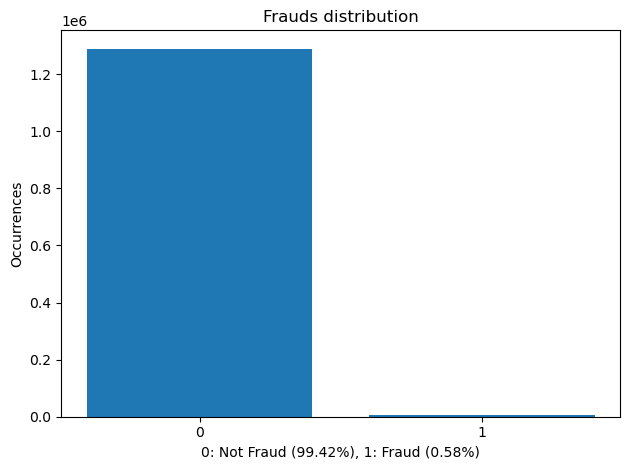

In [6]:
frauds=df["is_fraud"].value_counts()
fig,ax=plt.subplots()
ax.bar(frauds.index,frauds.values)
ax.set_xticks(frauds.index)
ax.set_title("Frauds distribution")
ax.set_xlabel(f"0: Not Fraud ({round(frauds[0]/frauds.sum()*100,2)}%), 1: Fraud ({round(frauds[1]/frauds.sum()*100,2)}%)")
ax.set_ylabel("Occurrences")

plt.tight_layout()
plt.show()

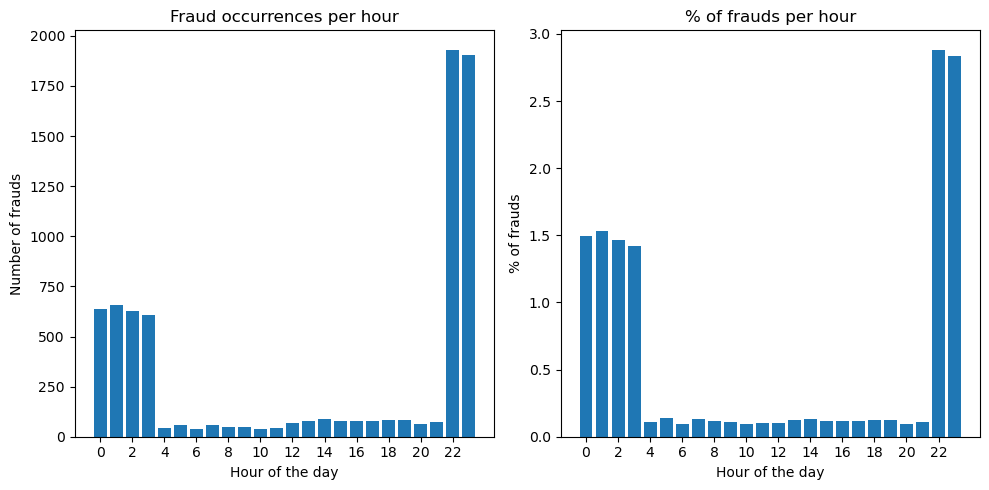

In [7]:
trans_hour=df["trans_date_trans_time"].dt.hour
fraud_hour=df["trans_date_trans_time"][df["is_fraud"]==1].dt.hour
trans_hour_counts=trans_hour.value_counts().sort_index()
fraud_hour_counts=fraud_hour.value_counts().sort_index()
perc_frauds=fraud_hour_counts/trans_hour_counts*100

fig,ax=plt.subplots(ncols=2, figsize=(10,5))
ax[0].bar(np.arange(24),fraud_hour_counts)
ax[0].set_xticks(np.arange(0,24,2))
ax[0].set_xlabel("Hour of the day")
ax[0].set_ylabel("Number of frauds")
ax[0].set_title("Fraud occurrences per hour")

ax[1].bar(np.arange(24),perc_frauds)
ax[1].set_xticks(np.arange(0,24,2))
ax[1].set_xlabel("Hour of the day")
ax[1].set_ylabel("% of frauds")
ax[1].set_title("% of frauds per hour")

plt.tight_layout()
plt.show()


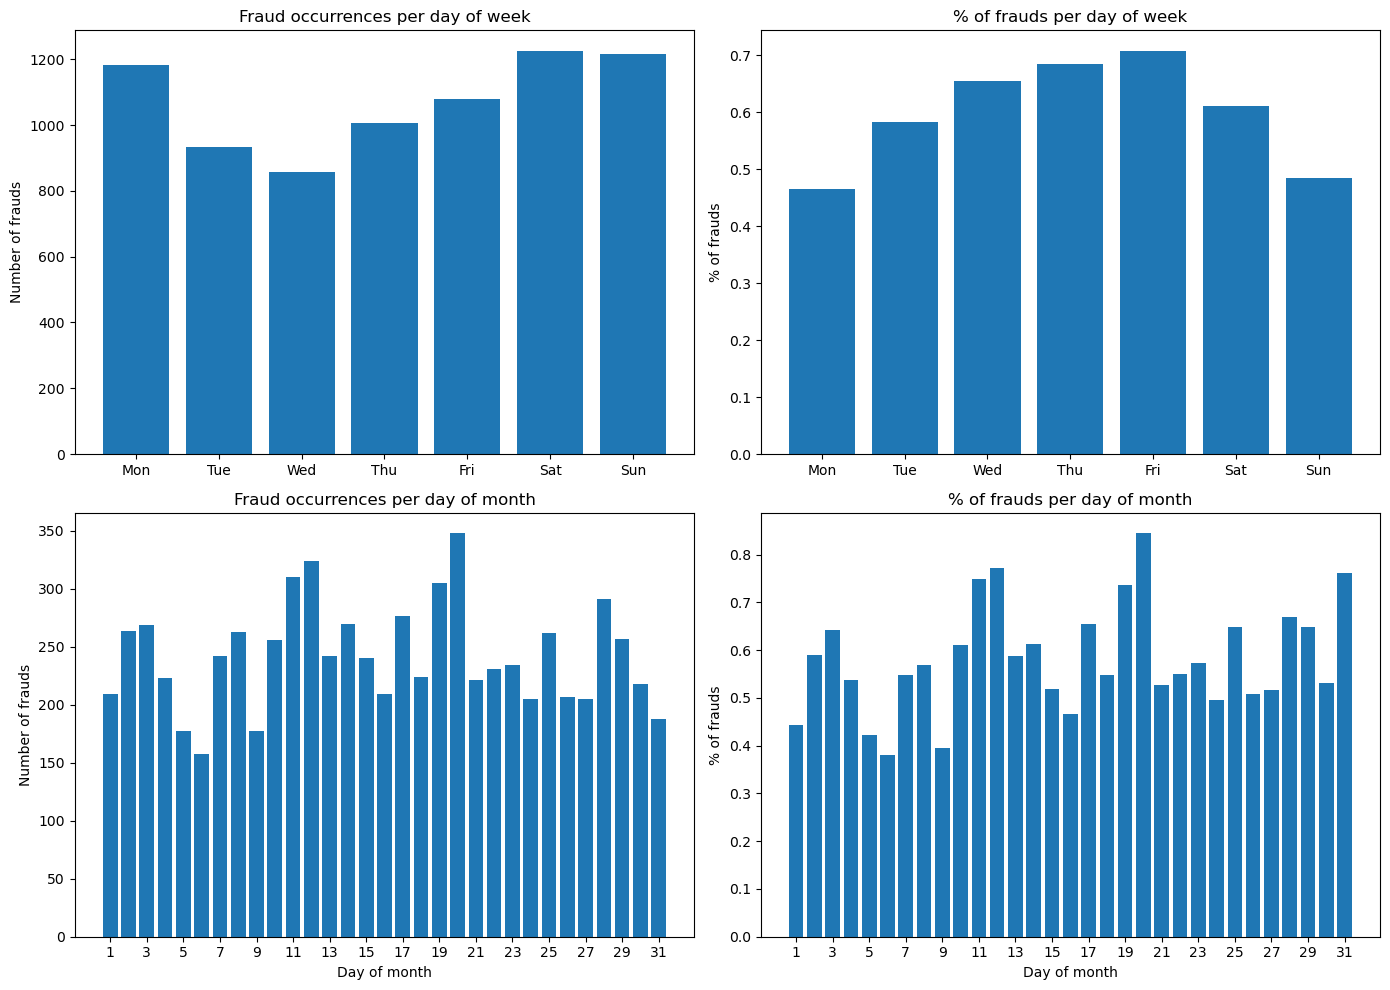

In [10]:
trans_dow = df["trans_date_trans_time"].dt.dayofweek
fraud_dow = df["trans_date_trans_time"][df["is_fraud"]==1].dt.dayofweek
trans_dow_counts = trans_dow.value_counts().sort_index()
fraud_dow_counts = fraud_dow.value_counts().sort_index()
perc_frauds_dow = (fraud_dow_counts / trans_dow_counts) * 100

dow = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']

fig, ax = plt.subplots(nrows=2, ncols=2, figsize=(14, 10))

ax[0, 0].bar(trans_dow_counts.index, fraud_dow_counts)
ax[0, 0].set_xticks(range(7))
ax[0, 0].set_xticklabels(dow)
ax[0, 0].set_ylabel("Number of frauds")
ax[0, 0].set_title("Fraud occurrences per day of week")

ax[0, 1].bar(trans_dow_counts.index, perc_frauds_dow)
ax[0, 1].set_xticks(range(7))
ax[0, 1].set_xticklabels(dow)
ax[0, 1].set_ylabel("% of frauds")
ax[0, 1].set_title("% of frauds per day of week")

trans_dom = df["trans_date_trans_time"].dt.day
fraud_dom = df["trans_date_trans_time"][df["is_fraud"]==1].dt.day
trans_dom_counts = trans_dom.value_counts().sort_index()
fraud_dom_counts = fraud_dom.value_counts().sort_index()
perc_frauds_dom = (fraud_dom_counts / trans_dom_counts) * 100

ax[1, 0].bar(trans_dom_counts.index, fraud_dom_counts)
ax[1, 0].set_xticks(range(1, 32, 2))
ax[1, 0].set_xlabel("Day of month")
ax[1, 0].set_ylabel("Number of frauds")
ax[1, 0].set_title("Fraud occurrences per day of month")

ax[1, 1].bar(trans_dom_counts.index, perc_frauds_dom)
ax[1, 1].set_xticks(range(1, 32, 2))
ax[1, 1].set_xlabel("Day of month")
ax[1, 1].set_ylabel("% of frauds")
ax[1, 1].set_title("% of frauds per day of month")


plt.tight_layout()
plt.show()

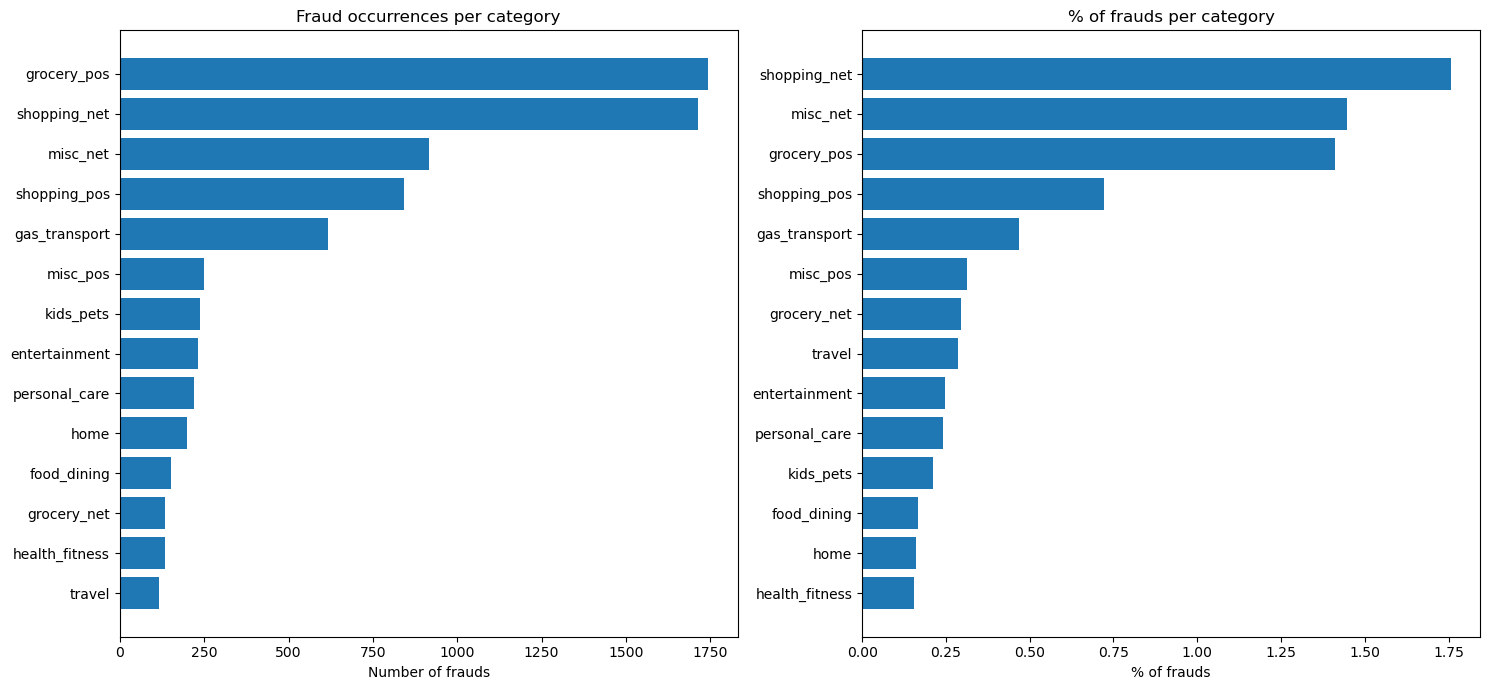

In [13]:
trans_cat = df["category"].value_counts()
fraud_cat = df[df["is_fraud"] == 1]["category"].value_counts()
perc_frauds_cat = (fraud_cat / trans_cat * 100).sort_values(ascending=True)
fraud_cat_sorted = fraud_cat.sort_values(ascending=True)

fig, ax = plt.subplots(ncols=2, figsize=(15, 7))

ax[0].barh(fraud_cat_sorted.index, fraud_cat_sorted.values)
ax[0].set_xlabel("Number of frauds")
ax[0].set_title("Fraud occurrences per category")

ax[1].barh(perc_frauds_cat.index, perc_frauds_cat.values)
ax[1].set_xlabel("% of frauds")
ax[1].set_title("% of frauds per category")

plt.tight_layout()
plt.show()

Stats legit transactions
count    1.289169e+06
mean     6.766711e+01
std      1.540080e+02
min      1.000000e+00
25%      9.610000e+00
50%      4.728000e+01
75%      8.254000e+01
max      2.894890e+04
Name: amt, dtype: float64

Stats frauds
count    7506.000000
mean      531.320092
std       390.560070
min         1.060000
25%       245.662500
50%       396.505000
75%       900.875000
max      1376.040000
Name: amt, dtype: float64


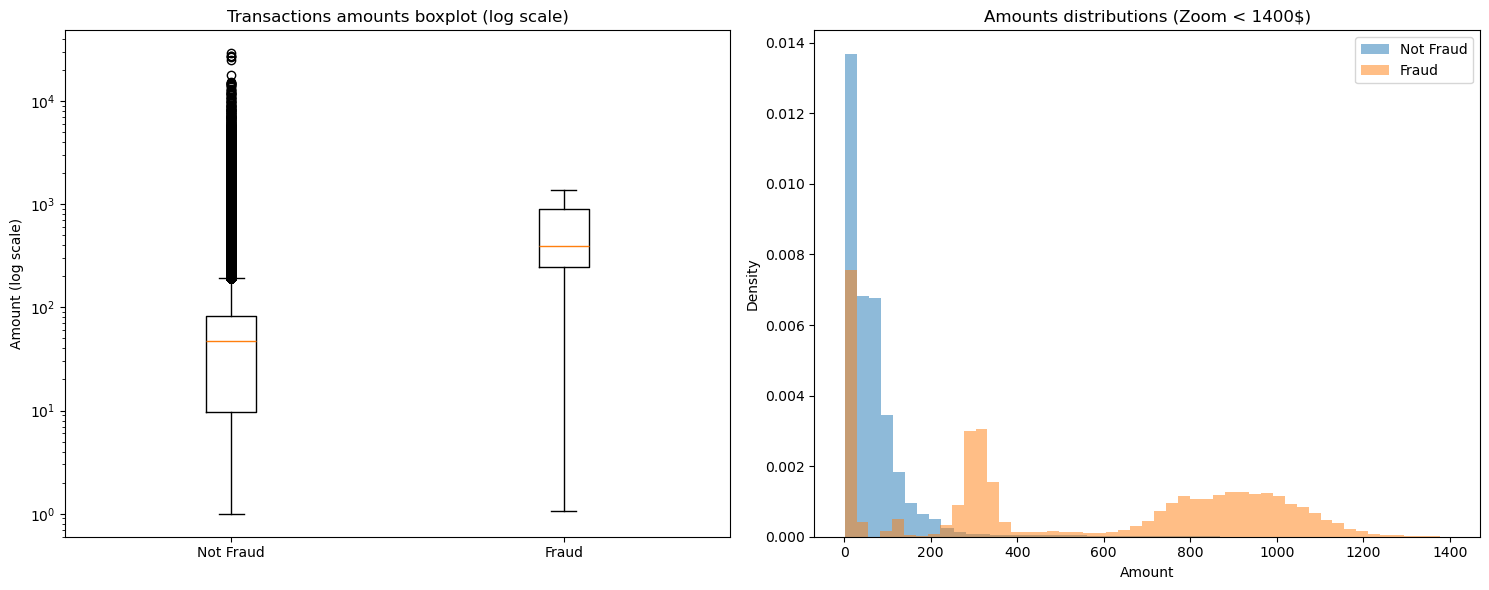

In [26]:
print("Stats legit transactions")
print(df[df['is_fraud'] == 0]['amt'].describe())
print("\nStats frauds")
print(df[df['is_fraud'] == 1]['amt'].describe())

fig, ax = plt.subplots(ncols=2, figsize=(15, 6))

ax[0].boxplot([df[df["is_fraud"]==0]["amt"], df[df["is_fraud"]==1]["amt"]], tick_labels=["Not Fraud", "Fraud"])
ax[0].set_yscale("log") 
ax[0].set_ylabel("Amount (log scale)")
ax[0].set_title("Transactions amounts boxplot (log scale)")

ax[1].hist(df[(df["is_fraud"]==0) & (df["amt"] < 1400)]["amt"], bins=50, alpha=0.5, label="Not Fraud", density=True)
ax[1].hist(df[(df["is_fraud"]==1) & (df["amt"] < 1400)]["amt"], bins=50, alpha=0.5, label="Fraud", density=True)
ax[1].set_xlabel("Amount")
ax[1].set_ylabel("Density")
ax[1].set_title("Amounts distributions (Zoom < 1400$)")
ax[1].legend()

plt.tight_layout()
plt.show()